# 1.1 Exploración de datos

**Actividad 1.1**
- Explica qué representa cada fila de la base y qué columnas la identifican.
- Indica cómo separarías la información en tablas o catálogos.
- Revisa si la base y los catálogos entregados coinciden entre sí.

**Contenido**
- **1.1.a** ¿Qué representa cada fila y qué columnas la identifican?
- **1.1.b** Estructura de datos propuesta (se explica en el README de `1_experimentacion`)
- **1.1.c** ¿El dataset y los catálogos coinciden? (vista general; el detalle está en `1_2_validacion_catalogos`)

</br>

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/1_crudos/KPIS_historico.xlsx` |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pd.set_option("display.max_colwidth", 80)

ARCHIVO = Path("../../0_datos/1_crudos/KPIS_historico.xlsx")
VERDE, AMARILLO, NARANJA, ROJO, AZUL, MORADO, ROSADO, GRIS, GRIS_CLARO = (
    "#00c389", "#fdda24", "#ff7f41", "#e03c31", "#59cbe8", "#9063cd", "#f5b6cd", "#9e9a99", "#e6e3e2")

In [2]:
def simplificar(texto):
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")


def limpiar_ejes(ax, lados=("top", "right")):
    ax.spines[list(lados)].set_visible(False)


def barra_apilada(ax, y, valores, colores, texto=lambda grupo, valor: f"{valor:,.0f}", minimo=0):
    inicio = 0
    for grupo, valor in valores.items():
        if valor == 0:
            continue
        ax.barh(y, valor, left=inicio, color=colores[grupo], edgecolor="white")
        if valor >= minimo:
            ax.text(inicio + valor / 2, y, texto(grupo, valor), ha="center", va="center", fontsize=8)
        else:
            ax.text(inicio + valor, y, " " + texto(grupo, valor), ha="left", va="center", fontsize=8)
        inicio += valor


def leyenda(ax, colores, ncol=5, y=-0.05):
    ax.legend(handles=[Patch(color=c, label=g) for g, c in colores.items()], frameon=False, ncol=ncol,
              loc="upper center", bbox_to_anchor=(0.5, y), fontsize=9)


def clasificar(dataset, catalogo, normalizar=None):
    ambos = dataset & catalogo
    distinto = set()
    if normalizar:
        dataset_norm = {normalizar(x): x for x in dataset - ambos}
        catalogo_norm = {normalizar(x): x for x in catalogo - ambos}
        distinto = {dataset_norm[n] for n in dataset_norm.keys() & catalogo_norm.keys()}
        catalogo = catalogo - {catalogo_norm[n] for n in dataset_norm.keys() & catalogo_norm.keys()}

    return {"En ambos": len(ambos), "Escrito distinto": len(distinto),
            "Solo en el dataset": len(dataset - ambos - distinto), "Solo en el catálogo": len(catalogo - ambos)}

In [3]:
kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype={"Corte": str, "Codigo_EQU": str, "EQU": str})
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)

## 1.1.a ¿Qué representa cada fila y qué columnas la identifican?

Una fila de `query` es **el resultado de un indicador, para un equipo, en un mes**: el equipo `Codigo_EQU` obtuvo `Resultado` frente a una `Meta` en el `Corte` (mes AAAAMM), y eso equivale a un `Cumplimiento`.

In [4]:
print("Muestra de los KPIs:")
display(kpis.drop(columns="codigo_equipo").sample(3, random_state=7))

llave = ["Corte", "Codigo_EQU", "Indicador"]
filas_unicas = kpis.drop(columns="codigo_equipo").drop_duplicates()
print("Resumen de la información:")
print("  Filas totales:", len(kpis))
print("  Meses:", kpis["Corte"].nunique(), f"({kpis['Corte'].min()} a {kpis['Corte'].max()})")
print("  Filas repetidas exactamente igual:", len(kpis) - len(filas_unicas))
print("  Combinaciones distintas de mes, equipo e indicador:", filas_unicas[llave].drop_duplicates().shape[0])
print("  ¿El frente cambia para un mismo mes, equipo e indicador?:", filas_unicas.groupby(llave)["Frente"].nunique().max() > 1)

Muestra de los KPIs:


,Frente,Corte,Codigo_EQU,EQU,Indicador,Resultado,Meta,Cumplimiento
13003,Experiencia,202603,EQU00061,Equipo 61,ICX,4.390000,4.0,1.097500
8327,Modelos de trabajo y Agilidad,202502,EQU00072,NaN,Percepción,3.611111,5.0,3.611111
10566,TI,202506,EQU00044,NaN,Apps modernizadas,1.000000,1.0,1.000000


Resumen de la información:
  Filas totales: 15188
  Meses: 44 (202301 a 202608)
  Filas repetidas exactamente igual: 2182
  Combinaciones distintas de mes, equipo e indicador: 11961
  ¿El frente cambia para un mismo mes, equipo e indicador?: False


**Respuesta:** la llave es **`Corte` + `Codigo_EQU` + `Indicador`**; `Frente` depende del indicador y `EQU` del código. Casi se cumple: hay filas repetidas y valores en conflicto (se cuantifican en `1_3_evaluacion_calidad`).

## 1.1.b Estructura de datos propuesta

Cómo separar la información en tablas o catálogos, qué representa cada una y por qué es una buena estructura se explica en el [README de experimentación](../README.md#11-estructura-de-datos-propuesta). La propuesta se apoya en la evidencia de 1.1.c, `1_2_validacion_catalogos` y `1_3_evaluacion_calidad`.

## 1.1.c ¿El dataset y los catálogos coinciden?

La coincidencia se mide **una sola vez y en ambos sentidos**: se juntan todos los indicadores (o equipos) que aparecen en cualquiera de las dos hojas y se clasifica cada uno según dónde está.

| Grupo | Significa |
|---|---|
| En ambos | está en el dataset y en el catálogo con el mismo nombre |
| Escrito distinto | está en ambos, pero el nombre cambia (por ejemplo, una tilde) |
| Solo en el dataset | se mide, pero el catálogo no lo conoce |
| Solo en el catálogo | está documentado, pero nadie lo mide |

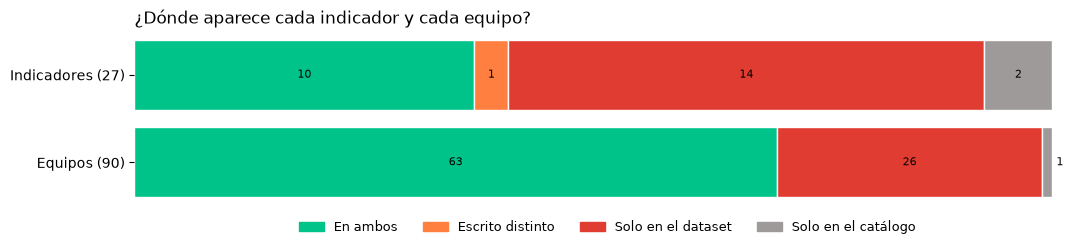

In [5]:
coincidencia = pd.DataFrame({
    "Indicadores": clasificar(set(kpis["Indicador"]), set(cat_indicadores["Indicador"]), simplificar),
    "Equipos": clasificar(set(kpis["codigo_equipo"].dropna()), set(cat_entornos["Codigo_EQU"])),
}).T
coincidencia["Total distintos"] = coincidencia.sum(axis=1)

colores = {"En ambos": VERDE, "Escrito distinto": NARANJA, "Solo en el dataset": ROJO, "Solo en el catálogo": GRIS}

fig, ax = plt.subplots(figsize=(11, 2.6))
for j, entidad in enumerate(["Equipos", "Indicadores"]):
    cantidades = coincidencia.loc[entidad, list(colores)]
    barra_apilada(ax, j, cantidades / cantidades.sum(), colores, minimo=0.03,
                  texto=lambda grupo, _, c=cantidades: f"{c[grupo]}")

ax.set_yticks([0, 1], [f"{e} ({coincidencia.loc[e, 'Total distintos']})" for e in ["Equipos", "Indicadores"]])
ax.set_xticks([])
ax.set_xlim(0, 1.03)
leyenda(ax, colores, ncol=4, y=-0.02)
ax.set_title("¿Dónde aparece cada indicador y cada equipo?", loc="left")
limpiar_ejes(ax, ("top", "right", "bottom", "left"))

plt.tight_layout()
plt.show()

**Respuesta:** **no coinciden del todo** y el desajuste está del lado del dataset: 14 indicadores (más de la mitad de las filas) y 26 equipos no existen en los catálogos. El detalle está en `1_2_validacion_catalogos`.